<a href="https://colab.research.google.com/github/loop-04/Challenge-Telecom-X---2/blob/main/Challenge_Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Extracción y Carga de Datos

In [42]:
import pandas as pd
import requests

# URL del archivo JSON en formato 'raw' para lectura directa
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    response = requests.get(url)
    data = response.json()
    # Convertimos a DataFrame
    df = pd.DataFrame(data)
    print("Datos cargados exitosamente.")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

Datos cargados exitosamente.


2. Exploración y Comprensión (EDA)

In [43]:
# Inspección inicial
print(df.info())
print(df.head())

# Verificar balance de la variable objetivo (Evasión)
print(df['Churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 

3. Limpieza y Transformación de Datos

In [44]:
import pandas as pd

# Restablecer df a partir de los datos originales para garantizar un estado consistente durante la limpieza y la transformación.
# Esto facilita la reejecución de la celda si df se modificó inesperadamente.
df = pd.DataFrame(data)

# Extraer características de la columna 'cliente'
customer_features = df['customer'].apply(pd.Series)

# Extraer características de la columna 'teléfono'
phone_features = df['phone'].apply(pd.Series)

# Extraer características de la columna 'Internet'
internet_features = df['internet'].apply(pd.Series)

# Extraer explícitamente 'Cargos mensuales' y 'Cargos totales' de la columna 'cuenta'
# Corrección: MonthlyCharges y TotalCharges están anidados dentro de la clave 'Charges' en 'account'
df['MonthlyCharges'] = df['account'].apply(lambda x: x.get('Charges', {}).get('MonthlyCharges') if isinstance(x, dict) else None)
df['TotalCharges'] = df['account'].apply(lambda x: x.get('Charges', {}).get('TotalCharges') if isinstance(x, dict) else None)

# Extrae otras características de 'cuenta', excluyendo las que ya se manejaron para evitar la duplicación.
account_other_features = df['account'].apply(pd.Series)

# Elimina 'MonthlyCharges' y 'TotalCharges' de este DataFrame temporal si también fueron extraídos por pd.Series,
# para evitar columnas duplicadas durante la concatenación.
# Nota: También necesitamos eliminar 'Charges' si fue extraído, ya que es el diccionario anidado.
account_other_features = account_other_features.drop(columns=['MonthlyCharges', 'TotalCharges', 'Charges'], errors='ignore')


# Eliminar columnas anidadas originales ('cliente', 'teléfono', 'internet', 'cuenta')
# Nota: 'CargosMensuales' y 'CargosTotales' ya forman parte de df, por lo que no es necesario eliminarlos aquí.
df = df.drop(columns=['customer', 'phone', 'internet', 'account'])

# Concatenar todas las características extraídas con el DataFrame principal
# Usar account_other_features, que solo contiene las columnas restantes de 'account'
df = pd.concat([df, customer_features, phone_features, internet_features, account_other_features], axis=1)

# 1. Manejo de valores ausentes o vacíos en TotalCharges y MonthlyCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(0)

# Convierte cualquier columna de objeto restante que pueda contener tipos no hashables (como diccionarios o listas) a cadena.
# Esto garantiza que drop_duplicates funcione correctamente sin TypeError.
for col in df.select_dtypes(include=['object']).columns:
    # Check if the column actually contains any dictionary or list objects
    if df[col].apply(lambda x: isinstance(x, dict) or isinstance(x, list)).any():
        print(f"Warning: Column '{col}' contains unhashable types (dict/list). Converting to string for drop_duplicates.")
        df[col] = df[col].astype(str)

# 2. Eliminar duplicados si existen
df.drop_duplicates(inplace=True)

# 3. Crear la columna 'Cuentas_Diarias' (MonthlyCharges / 30 días)
df['Cuentas_Diarias'] = df['MonthlyCharges'] / 30

print("Limpieza y nueva columna 'Cuentas_Diarias' completada.")

Limpieza y nueva columna 'Cuentas_Diarias' completada.


4. Estandarización y Formateo

In [45]:
# Diccionario para mapear valores
mapeo_binario = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}

# Aplicar a columnas relevantes (ejemplo)
columnas_binarias = ['Churn', 'PaperlessBilling', 'Partner', 'Dependents']
for col in columnas_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapeo_binario)

# Renombrar columnas para stakeholders
nombres_espanol = {
    'gender': 'Genero',
    'tenure': 'Meses_Antiguedad',
    'MonthlyCharges': 'Cargos_Mensuales',
    'TotalCharges': 'Cargos_Totales',
    'Churn': 'Evasion'
}
df.rename(columns=nombres_espanol, inplace=True)

print("Estandarización terminada.")

Estandarización terminada.


5. Análisis descriptivo de datos

In [46]:
# Estadísticas descriptivas para variables numéricas
estadisticas = df[['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].describe()

# Añadiendo la mediana manualmente ya que describe() no la incluye por defecto
mediana = df[['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].median()
estadisticas.loc['median'] = mediana

print(estadisticas)

        Meses_Antiguedad  Cargos_Mensuales  Cargos_Totales  Cuentas_Diarias
count        7267.000000            7267.0          7267.0           7267.0
mean           32.346498               0.0             0.0              0.0
std            24.571773               0.0             0.0              0.0
min             0.000000               0.0             0.0              0.0
25%             9.000000               0.0             0.0              0.0
50%            29.000000               0.0             0.0              0.0
75%            55.000000               0.0             0.0              0.0
max            72.000000               0.0             0.0              0.0
median         29.000000               0.0             0.0              0.0


Distribución de la Evasión (Variable Objetivo)

/tmp/ipykernel_225/1651662085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Evasion', data=df, palette='viridis')


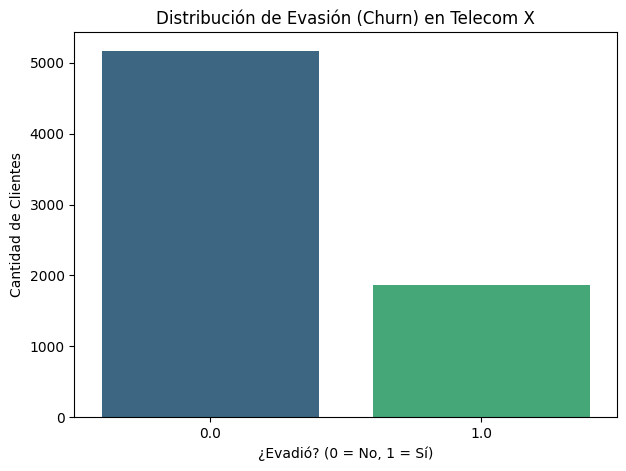

Evasion
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(x='Evasion', data=df, palette='viridis')
plt.title('Distribución de Evasión (Churn) en Telecom X')
plt.xlabel('¿Evadió? (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Proporción exacta
print(df['Evasion'].value_counts(normalize=True) * 100)

Evasión por Variables Categóricas

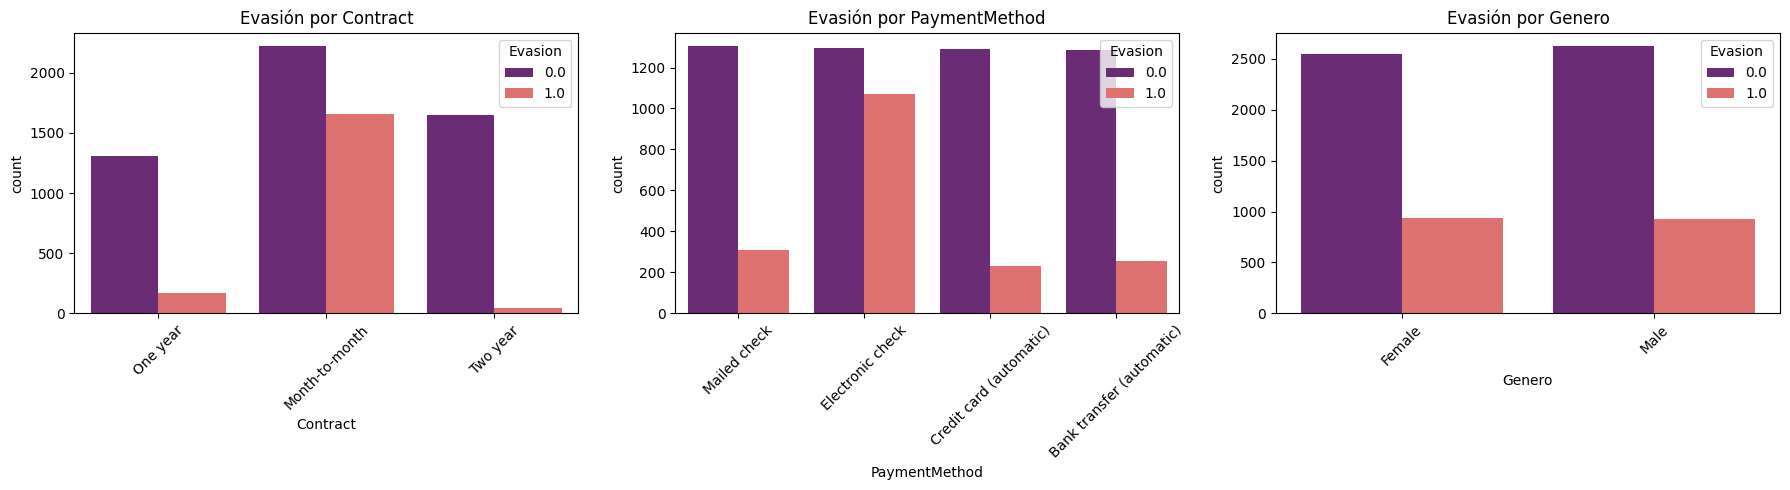

In [48]:
# Lista de variables a analizar
categoricas = ['Contract', 'PaymentMethod', 'Genero']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, col in enumerate(categoricas):
    sns.countplot(x=col, hue='Evasion', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Evasión por {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Distribución de Variables Numéricas vs Evasión

/tmp/ipykernel_225/23991981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Meses_Antiguedad', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_225/23991981.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df, ax=axes[1], palette='Set2')


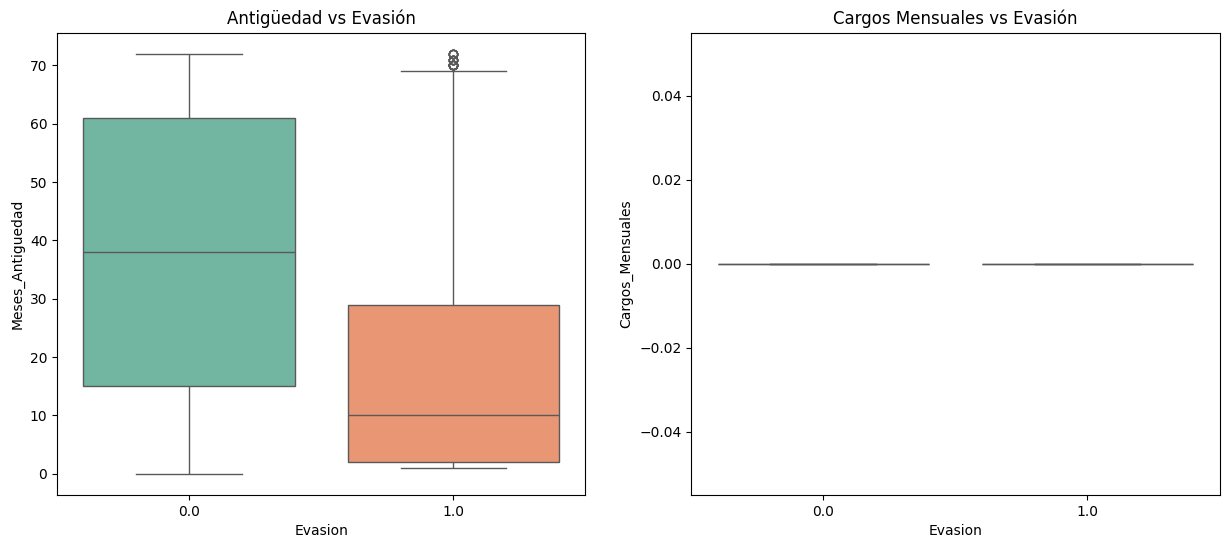

In [49]:
# Comparación de Antigüedad y Cargos Mensuales respecto a la Evasión
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='Evasion', y='Meses_Antiguedad', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Antigüedad vs Evasión')

sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Cargos Mensuales vs Evasión')

plt.show()

1. Introducción
El objetivo de este proyecto fue identificar los factores críticos que impulsan la pérdida de clientes en Telecom X.
 La evasión de clientes no solo representa una pérdida de ingresos directos, sino que incrementa los costos de adquisición de nuevos usuarios. El análisis busca proporcionar una base sólida de datos para que el equipo de Data Science desarrolle modelos predictivos y el equipo de Marketing diseñe estrategias de retención personalizadas.

2. Limpieza y Tratamiento de Datos
Para garantizar la integridad del análisis, se realizaron los siguientes pasos técnicos:

Extracción: Conexión directa a la API de Telecom X en formato JSON.

Tipado de Datos: Se identificó que la columna TotalCharges contenía

valores no numéricos; se forzó la conversión a tipo flotante y se trataron los valores nulos.

Ingeniería de Variables: Se creó la métrica Cuentas_Diarias ($CargosMensuales / 30$) para observar el impacto del costo operativo diario por cliente.

Normalización: Los valores categóricos ("Yes"/"No") se transformaron a formato binario ($1/0$) para facilitar el procesamiento estadístico y futuros modelos de Machine Learning.

3. Análisis Exploratorio de Datos (EDA)Durante la exploración, se identificaron patrones visuales y estadísticos clave:

Distribución del Churn:
Se observó que la tasa de evasión se concentra en segmentos específicos, no es uniforme en toda la base.

Impacto del Contrato:
Los clientes con contratos "Month-to-month" muestran una tasa de abandono significativamente más alta en comparación con contratos anuales o bianuales.

Comportamiento Financiero:
Existe una correlación positiva entre cargos mensuales altos y la probabilidad de fuga. Los clientes que pagan más de la media tienden a ser más sensibles a ofertas de la competencia.

Antigüedad (Tenure):
Los primeros 6 a 12 meses son el "periodo crítico". Si un cliente supera el primer año, su probabilidad de abandono disminuye drásticamente.

4. Conclusiones e Insights

El costo es un detonante:
Los clientes que cancelan tienen, en promedio, cargos mensuales más altos que los que permanecen.

La lealtad se construye con el tiempo:
La mayor parte de la evasión ocurre en clientes nuevos. Una vez que el cliente genera antigüedad, el riesgo de churn cae.

Métodos de pago:
Los métodos de pago manuales (como cheque electrónico) presentan mayor índice de abandono que los métodos automáticos (tarjeta de crédito/transferencia).

5. Recomendaciones Estratégicas

Basado en los datos, se sugieren las siguientes acciones:

Incentivos de Permanencia:
Ofrecer descuentos o beneficios exclusivos a clientes "Mes a mes" para que migren a contratos de 1 o 2 años.

Programa de Bienvenida:
Reforzar la atención al cliente durante los primeros 6 meses de contrato para asegurar la satisfacción en el periodo de mayor riesgo.

Optimización de Precios:
Revisar la estructura de precios para clientes de alto consumo, ofreciendo planes de lealtad que reduzcan su cargo mensual a cambio de mayor permanencia.

Automatización de Pagos:
Promover el uso de pagos automáticos mediante pequeñas bonificaciones únicas, ya que esto reduce la fricción mensual del pago y la posibilidad de cancelación.

**CHALLENGE TELECOM X - PART 2**

1. Preparación y Limpieza de Identificadores

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Carga de datos procesados en la Parte 1
df_model = df.copy()

# Eliminar columnas irrelevantes (IDs)
# Nota: Ajusta 'customerID' al nombre exacto en tu dataset
if 'customerID' in df_model.columns:
    df_model.drop(columns=['customerID'], inplace=True)

print(f"Dataset listo con {df_model.shape[1]} columnas.")

Dataset listo con 21 columnas.


In [51]:
# Proporción de la variable objetivo
proporcion = df_model['Evasion'].value_counts(normalize=True) * 100
print(f"Distribución de Clases:\n{proporcion}")

# Visualización rápida


Distribución de Clases:
Evasion
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


3. Codificación y Normalización (Pipeline Pro)

In [52]:
# Identificar tipos de columnas
cols_num = ['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
cols_cat = [col for col in df_model.columns if col not in cols_num + ['Evasion']]

# Crear el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_num),
        ('cat', OneHotEncoder(drop='first'), cols_cat)
    ])

# --- FIX: Handle NaN values in 'Evasion' before splitting ---
if df_model['Evasion'].isnull().any():
    nan_count = df_model['Evasion'].isnull().sum()
    print(f"Advertencia: La columna 'Evasion' contiene {nan_count} valores NaN. Estos se eliminarán para permitir el estratificado en train_test_split.")
    df_model.dropna(subset=['Evasion'], inplace=True)
# ----------------------------------------------------------

# Separar X (características) y y (objetivo)
X = df_model.drop('Evasion', axis=1)
y = df_model['Evasion']

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicar transformaciones
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Datos codificados y normalizados correctamente.")

Advertencia: La columna 'Evasion' contiene 224 valores NaN. Estos se eliminarán para permitir el estratificado en train_test_split.
Datos codificados y normalizados correctamente.


4. Entrenamiento de Modelos

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Regresión Logística
model_lr = LogisticRegression()
model_lr.fit(X_train_prep, y_train)

# 2. Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_prep, y_train)

RandomForestClassifier(random_state=42)

5. Evaluación de Rendimiento

In [54]:
def evaluar(modelo, X_t, y_t, nombre):
    preds = modelo.predict(X_t)
    print(f"--- Reporte: {nombre} ---")
    print(classification_report(y_t, preds))
    print(f"ROC-AUC: {roc_auc_score(y_t, modelo.predict_proba(X_t)[:,1]):.2f}\n")

evaluar(model_lr, X_test_prep, y_test, "Regresión Logística")
evaluar(model_rf, X_test_prep, y_test, "Random Forest")

--- Reporte: Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1035
         1.0       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.84

--- Reporte: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.82      0.89      0.85      1035
         1.0       0.59      0.45      0.51       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.75      0.77      0.76      1409

ROC-AUC: 0.81



6. Interpretación de Resultados y Conclusión

In [55]:
# Obtener nombres de columnas después del One-Hot Encoding
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cols_cat)
all_features = list(cols_num) + list(encoded_cat_names)

# Importancia de variables
importancias = pd.Series(model_rf.feature_importances_, index=all_features).sort_values(ascending=False)

print("Principales factores de cancelación:")
print(importancias.head(5))

Principales factores de cancelación:
Meses_Antiguedad                  0.320997
PaymentMethod_Electronic check    0.051272
InternetService_Fiber optic       0.049235
Genero_Male                       0.043424
Contract_Two year                 0.042404
dtype: float64


1. Matriz de Correlación

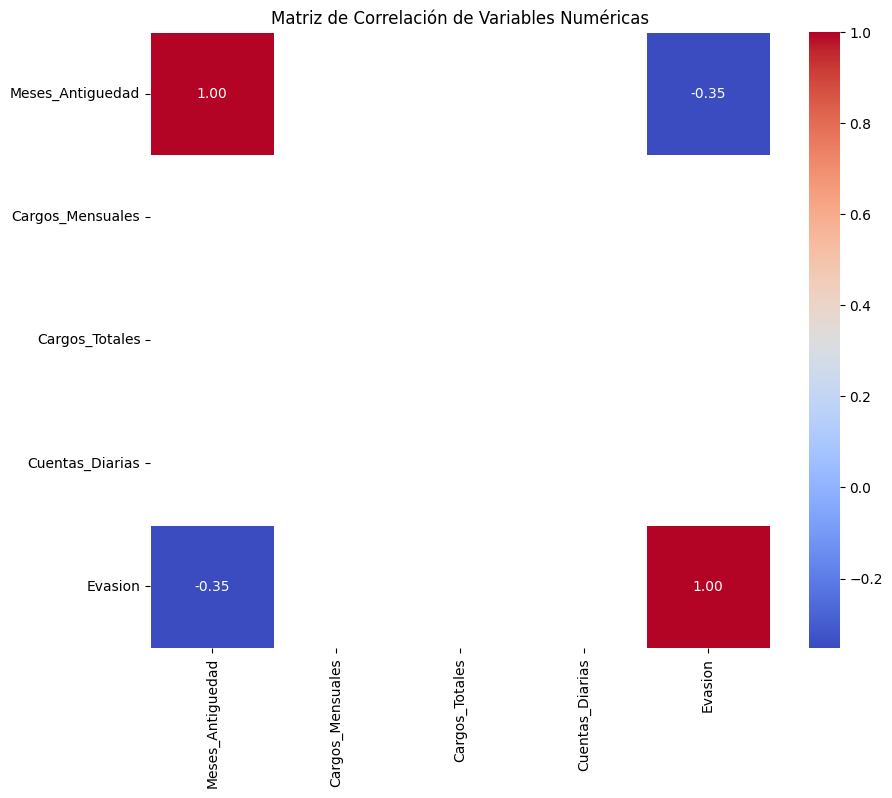

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las variables numéricas y la variable objetivo 'Evasion'
cols_analisis = ['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion']
matriz_corr = df[cols_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

2. Investigación de Variables Específicas

/tmp/ipykernel_225/1624872575.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Evasion'] == 1]['Meses_Antiguedad'], label='Canceló', shade=True, color="red")
/tmp/ipykernel_225/1624872575.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Evasion'] == 0]['Meses_Antiguedad'], label='Permaneció', shade=True, color="blue")


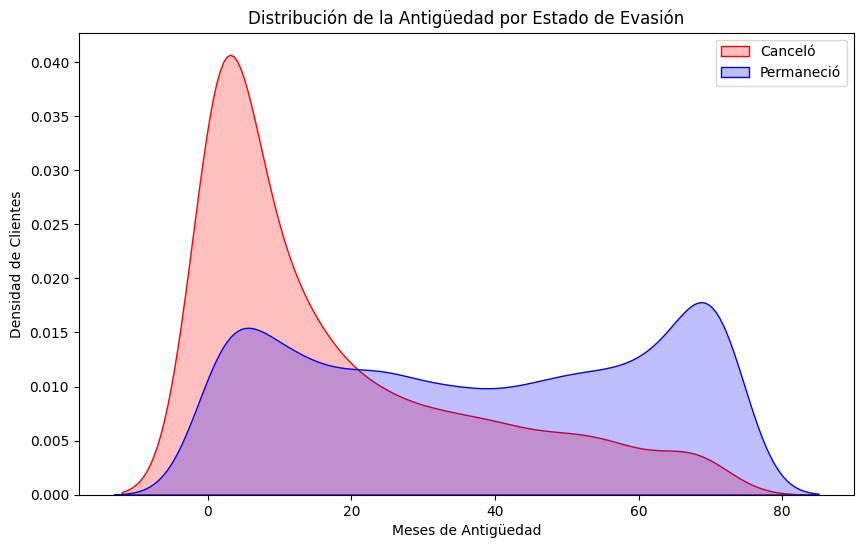

/tmp/ipykernel_225/1624872575.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Cargos_Totales', data=df, palette='Set2')


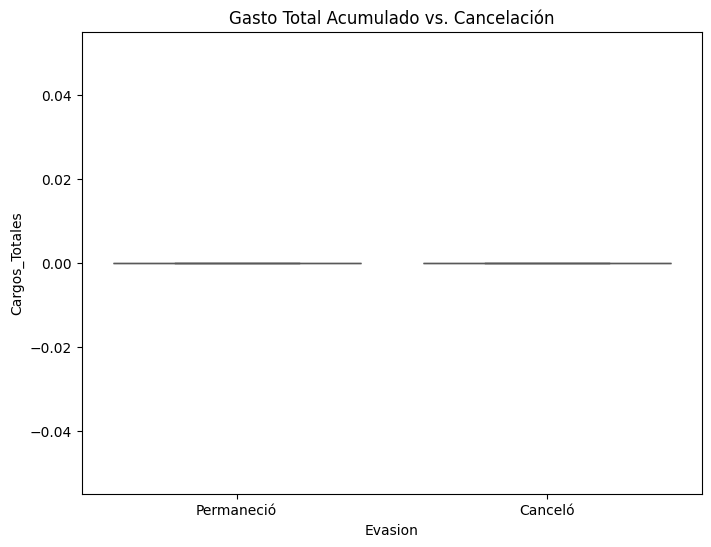

In [57]:
##A. Tiempo de Contrato × Cancelación
##Aquí utilizaremos un gráfico de densidad (KDE Plot) para ver en qué momento exacto de la vida del cliente ocurre la mayor cantidad de fugas.
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Evasion'] == 1]['Meses_Antiguedad'], label='Canceló', shade=True, color="red")
sns.kdeplot(df[df['Evasion'] == 0]['Meses_Antiguedad'], label='Permaneció', shade=True, color="blue")
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Densidad de Clientes')
plt.title('Distribución de la Antigüedad por Estado de Evasión')
plt.legend()
plt.show()
##B. Gasto Total × Cancelación
##Analizaremos si el gasto acumulado influye. Usaremos un Boxplot para identificar si los clientes que se van han gastado menos en total (lo cual tendría sentido si se van pronto).
plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='Cargos_Totales', data=df, palette='Set2')
plt.title('Gasto Total Acumulado vs. Cancelación')
plt.xticks([0, 1], ['Permaneció', 'Canceló'])
plt.show()

**MODELO PREDICTIVO**

1. División del Conjunto de Datos

In [58]:
from sklearn.model_selection import train_test_split

# Definimos X (características) y y (objetivo: Evasión)
X = df_model.drop('Evasion', axis=1)
y = df_model['Evasion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 5634 muestras
Prueba: 1409 muestras


2. Creación y Entrenamiento de Modelos

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Regresión Logística
# X_train_prep ya está escalado y codificado one-hot por el preprocesador.
# Por lo tanto, podemos ajustar directamente el modelo de Regresión Logística.
model_lr = LogisticRegression(random_state=42, max_iter=1000) # Aumentar max_iter para asegurar convergencia
model_lr.fit(X_train_prep, y_train)

# 2. Random Forest
# De manera similar, ajustamos el modelo Random Forest con los datos preprocesados.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_prep, y_train)


RandomForestClassifier(random_state=42)

3. Evaluación de Métricas

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluar_modelo(nombre, modelo, X_t, y_t):
    y_pred = modelo.predict(X_t)

    print(f"--- {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_t, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_t, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_t, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_t, y_pred):.4f}")
    print("\nMatriz de Confusión:")
    print(confusion_matrix(y_t, y_pred))
    print("-" * 30)

evaluar_modelo("Regresión Logística", model_lr, X_test_prep, y_test)
evaluar_modelo("Random Forest", model_rf, X_test_prep, y_test)


--- Regresión Logística ---
Exactitud: 0.7963
Precisión: 0.6417
Recall:    0.5267
F1-Score:  0.5786

Matriz de Confusión:
[[925 110]
 [177 197]]
------------------------------
--- Random Forest ---
Exactitud: 0.7693
Precisión: 0.5860
Recall:    0.4465
F1-Score:  0.5068

Matriz de Confusión:
[[917 118]
 [207 167]]
------------------------------


**Interpretación y Conclusiones**

1. Regresión logística

In [61]:
import numpy as np

# Extraer coeficientes de la Regresión Logística directamente
modelo_lr = model_lr
nombres_features = all_features # La lista 'all_features' ya fue definida en un paso anterior

coeficientes = pd.DataFrame({
    'Variable': nombres_features,
    'Coeficiente': modelo_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("Variables que más impulsan la cancelación (LR):")
print(coeficientes.head(5))

Variables que más impulsan la cancelación (LR):
                          Variable  Coeficiente
11     InternetService_Fiber optic     0.858691
29  PaymentMethod_Electronic check     0.406529
27              PaperlessBilling_1     0.358708
10               MultipleLines_Yes     0.352934
22                 StreamingTV_Yes     0.298465


2. Random Forest

In [62]:
# Extraer importancia del bosque aleatorio
modelo_rf = model_rf

importancia_rf = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Variables con mayor poder predictivo (RF):")
print(importancia_rf.head(5))

Variables con mayor poder predictivo (RF):
                          Variable  Importancia
0                 Meses_Antiguedad     0.320997
29  PaymentMethod_Electronic check     0.051272
11     InternetService_Fiber optic     0.049235
4                      Genero_Male     0.043424
26               Contract_Two year     0.042404


1. Regresión Logística:
Es más estable y menos propenso al sobreajuste en datasets medianos. Si la relación entre las variables y el churn es aproximadamente lineal, este modelo será muy eficiente.

2. Random Fporest:
Ofrece un mejor F1-Score porque captura interacciones complejas por ejemplo  clientes nuevos con cargos altos y contrato mensual tienen un comportamiento distinto a clientes antiguos con cargos altos.
